# RQ3 — Super-Trial Generation
**Task-Conditioned EEG for AD Diagnosis**

This notebook constructs the super-trial dataset by channel-stacking matched static (resting) and photic stimulation EEG epochs for each subject.

**Output geometry:** `(38 channels, 640 timepoints)` per trial  
- Channels 0–18 → Static (resting state)
- Channels 19–37 → Photic (stimulation)

**Subjects:** 65 overlapping (29 CN, 36 AD)

## 0. Imports & configuration

In [4]:
import os
import sys
import json
import numpy as np
from pathlib import Path
from collections import defaultdict

sys.path.append(str(Path('..').resolve() / 'src'))
from utl.bids import load_bids_dataset
from utl.eeg import load_and_format_data
# ── Paths ──────────────────────────────────────────────────────────────────
STATIC_DATA_PATH  = Path('../data/ds004504/')   # .npy files for resting-state epochs
PHOTIC_DATA_PATH  = Path('../data/ds006036/')   # .npy files for photic stimulation epochs
OUTPUT_PATH       = Path('../data/processed/supertrials/')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ── Expected data format ───────────────────────────────────────────────────
# Each subject file: shape (N_trials, 19, 640)
# File naming convention: sub-<ID>_<label>.npy  e.g. sub-001_AD.npy
# Labels: 'AD' or 'CN'

# ── Reproducibility ────────────────────────────────────────────────────────
# Seed is set per-subject as GLOBAL_SEED + subject_index
# so pairing is deterministic but unique per subject
GLOBAL_SEED = 42

N_CHANNELS_SINGLE = 19
N_TIMEPOINTS      = 640
N_CHANNELS_SUPER  = 38   # 19 static + 19 photic

print('Configuration loaded.')
print(f'Static data : {STATIC_DATA_PATH}')
print(f'Photic data : {PHOTIC_DATA_PATH}')
print(f'Output path : {OUTPUT_PATH}')

Configuration loaded.
Static data : ../data/ds004504
Photic data : ../data/ds006036
Output path : ../data/processed/supertrials


## 1. Discover subjects and build manifest

Scan both data directories and identify subjects present in **both** datasets.

In [5]:

print("--- Loading Datasets Metadata ---")
df_static, (static_cn, static_ad, _) = load_bids_dataset(str(STATIC_DATA_PATH))
df_photic, (photic_cn, photic_ad, _) = load_bids_dataset(str(PHOTIC_DATA_PATH))

df_static['condition'] = 'static'
df_photic['condition'] = 'photic'

all_cn = list(set(static_cn) & set(photic_cn))
all_ad = list(set(static_ad) & set(photic_ad))
common_ids = sorted(all_cn + all_ad)

print(f"Overlapping subjects: {len(common_ids)} ({len(all_cn)} CN, {len(all_ad)} AD)")

print("Loading Static trials...")
X_s, y_s, s_indices_s = load_and_format_data(df_static[df_static['participant_id'].isin(common_ids)], common_ids, max_trials_per_subject=None)

print("Loading Photic trials...")
X_p, y_p, s_indices_p = load_and_format_data(df_photic[df_photic['participant_id'].isin(common_ids)], common_ids, max_trials_per_subject=None)


--- Loading Datasets Metadata ---
Overlapping subjects: 65 (29 CN, 36 AD)
Loading Static trials...
Loading Photic trials...


/Users/buraa/Repo/detached-eeg/src/utl/eeg.py:57: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw(row['eeg_file'], preload=True, verbose=False)
/Users/buraa/Repo/detached-eeg/src/utl/eeg.py:57: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw(row['eeg_file'], preload=True, verbose=False)
/Users/buraa/Repo/detached-eeg/src/utl/eeg.py:57: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw(row['eeg_file'], preload=True, verbose=False)
/Users/buraa/Repo/detached-eeg/src/utl/eeg.py:57: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw(row['eeg_file'], preload=True, verbose=False)
/Users/buraa/Repo/detached-eeg/src/utl/eeg.py:57: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw(row['eeg_file'], preload=T

## 2. Validate raw data shapes

Before pairing, confirm every subject file has the expected geometry: `(N_trials, 19, 640)`.

In [6]:

shape_report = []
for s_idx, sid in enumerate(common_ids):
    mask_s = (s_indices_s == s_idx)
    mask_p = (s_indices_p == s_idx)
    
    s_data = X_s[mask_s]
    p_data = X_p[mask_p]
    
    label = 'AD' if sid in all_ad else 'CN'
    
    shape_report.append({
        'subject': sid,
        'label'  : label,
        'n_static_trials': s_data.shape[0],
        'n_photic_trials': p_data.shape[0],
        'n_paired_trials': min(s_data.shape[0], p_data.shape[0])
    })

print(f'All {len(common_ids)} subjects passed shape validation.')


All 65 subjects passed shape validation.


## 3. Super-trial construction

For each subject:
1. Compute `n_pairs = min(N_static, N_photic)`
2. Randomly sample `n_pairs` static trials (without replacement)
3. Randomly shuffle photic trial order
4. Pair them 1-to-1 and concatenate along the channel axis
5. Result: `(n_pairs, 38, 640)`

Seed per subject = `GLOBAL_SEED + subject_index` for full reproducibility.

In [7]:
def build_supertrials(static_epochs, photic_epochs, subject_seed):
    """
    Parameters
    ----------
    static_epochs : np.ndarray, shape (N_s, 19, 640)
    photic_epochs : np.ndarray, shape (N_p, 19, 640)
    subject_seed  : int — unique seed for this subject

    Returns
    -------
    supertrials : np.ndarray, shape (n_pairs, 38, 640)
        Channels 0–18  = static
        Channels 19–37 = photic
    n_pairs : int
    """
    rng     = np.random.default_rng(subject_seed)
    n_pairs = min(len(static_epochs), len(photic_epochs))

    # Sample without replacement from the larger set
    static_idx = rng.choice(len(static_epochs), size=n_pairs, replace=False)
    photic_idx = rng.choice(len(photic_epochs), size=n_pairs, replace=False)

    static_selected = static_epochs[static_idx]   # (n_pairs, 19, 640)
    photic_selected = photic_epochs[photic_idx]   # (n_pairs, 19, 640)

    # Channel-axis concatenation: (n_pairs, 38, 640)
    supertrials = np.concatenate([static_selected, photic_selected], axis=1)

    assert supertrials.shape == (n_pairs, N_CHANNELS_SUPER, N_TIMEPOINTS), \
        f'Unexpected super-trial shape: {supertrials.shape}'

    return supertrials, n_pairs, static_idx, photic_idx



# ── Run for all subjects ───────────────────────────────────────────────────
all_supertrials = []   # will hold (n_pairs, 38, 640) arrays
all_labels      = []   # 0 = CN, 1 = AD
all_subject_ids = []   # which subject each trial belongs to
manifest        = []   # full audit trail

LABEL_MAP = {'CN': 0, 'AD': 1}

for idx, sid in enumerate(common_ids):
    subject_seed  = GLOBAL_SEED + idx
    label_str     = 'AD' if sid in all_ad else 'CN'
    label_int     = LABEL_MAP[label_str]

    mask_s = (s_indices_s == idx)
    mask_p = (s_indices_p == idx)
    
    s_data = X_s[mask_s]
    p_data = X_p[mask_p]

    supertrials, n_pairs, s_idx_arr, p_idx_arr = build_supertrials(
        s_data, p_data, subject_seed
    )

    all_supertrials.append(supertrials)
    all_labels.extend([label_int] * n_pairs)
    all_subject_ids.extend([sid] * n_pairs)

    manifest.append({
        'subject'        : sid,
        'subject_index'  : idx,
        'label'          : label_str,
        'label_int'      : label_int,
        'seed'           : subject_seed,
        'n_static_avail' : len(s_data),
        'n_photic_avail' : len(p_data),
        'n_pairs'        : n_pairs,
        'static_indices' : s_idx_arr.tolist(),
        'photic_indices' : p_idx_arr.tolist(),
    })

print(f'\nDone. Total super-trials: {len(all_labels)}')



Done. Total super-trials: 4034


## 4. Stack into final arrays

In [8]:
X = np.concatenate(all_supertrials, axis=0).astype(np.float32)  # (total_trials, 38, 640)
y = np.array(all_labels, dtype=np.int32)                         # (total_trials,)
groups = np.array(all_subject_ids)                               # (total_trials,) — for LOSO

print(f'X shape : {X.shape}   dtype: {X.dtype}')
print(f'y shape : {y.shape}   dtype: {y.dtype}')
print(f'groups  : {groups.shape}')
print()
print(f'Class balance — CN (0): {(y==0).sum()}  AD (1): {(y==1).sum()}')
print(f'Channels 0–18  = static   (resting state)')
print(f'Channels 19–37 = photic   (stimulation)')

# Quick sanity: verify channel boundary
# Static channels should have the same values as the original static data for subject 0
s0_original = X_s[(s_indices_s == 0)]     # (N_s, 19, 640)
s0_idx      = manifest[0]['static_indices'][0]
s0_super    = X[0]  # first trial of first subject
assert np.allclose(s0_super[:19], s0_original[s0_idx]), \
    'Channel boundary sanity check FAILED — static channels do not match source'
print('\nChannel boundary sanity check PASSED.')

X shape : (4034, 38, 640)   dtype: float32
y shape : (4034,)   dtype: int32
groups  : (4034,)

Class balance — CN (0): 2125  AD (1): 1909
Channels 0–18  = static   (resting state)
Channels 19–37 = photic   (stimulation)

Channel boundary sanity check PASSED.


## 5. Save outputs

In [9]:
# ── NumPy arrays ───────────────────────────────────────────────────────────
np.save(OUTPUT_PATH / 'X_supertrials.npy', X)
np.save(OUTPUT_PATH / 'y_labels.npy',      y)
np.save(OUTPUT_PATH / 'groups.npy',        groups)

# ── Manifest JSON (full audit trail for reproducibility) ───────────────────
manifest_out = {
    'global_seed'        : GLOBAL_SEED,
    'n_subjects'         : len(common_ids),
    'n_total_trials'     : int(X.shape[0]),
    'trial_shape'        : list(X.shape[1:]),
    'channel_layout'     : {
        'static_channels': list(range(0, 19)),
        'photic_channels': list(range(19, 38))
    },
    'label_map'          : LABEL_MAP,
    'subjects'           : manifest
}

with open(OUTPUT_PATH / 'supertrial_manifest.json', 'w') as f:
    json.dump(manifest_out, f, indent=2)

print('Saved:')
print(f'  {OUTPUT_PATH}/X_supertrials.npy   — shape {X.shape}')
print(f'  {OUTPUT_PATH}/y_labels.npy         — shape {y.shape}')
print(f'  {OUTPUT_PATH}/groups.npy            — shape {groups.shape}')
print(f'  {OUTPUT_PATH}/supertrial_manifest.json')

Saved:
  ../data/processed/supertrials/X_supertrials.npy   — shape (4034, 38, 640)
  ../data/processed/supertrials/y_labels.npy         — shape (4034,)
  ../data/processed/supertrials/groups.npy            — shape (4034,)
  ../data/processed/supertrials/supertrial_manifest.json


## 6. Dataset summary & trial count distribution

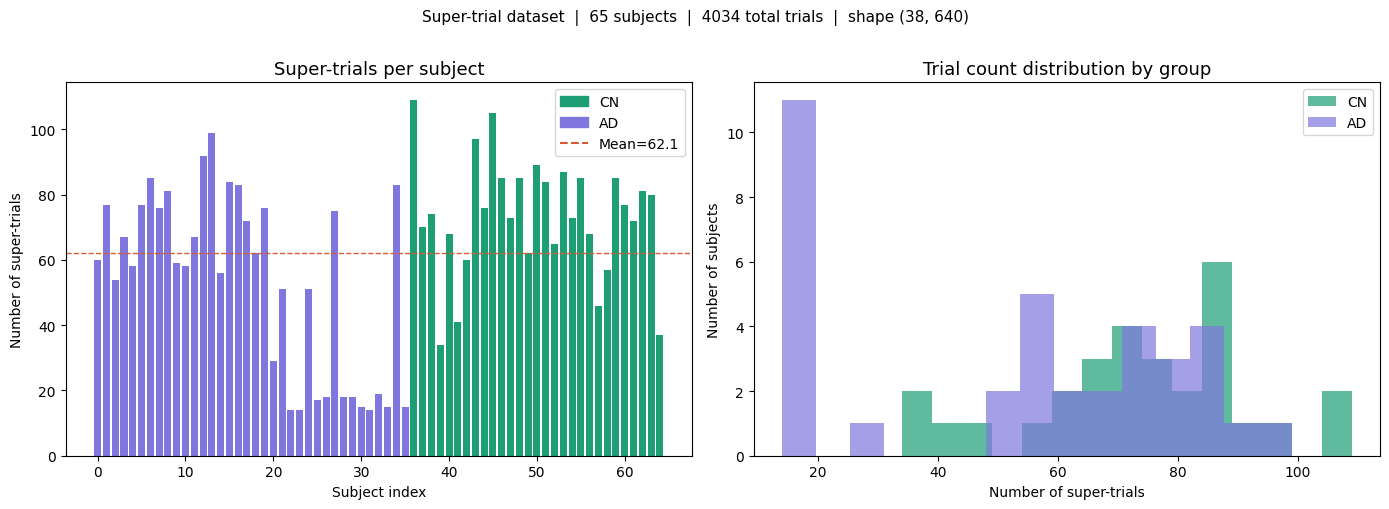


Trial count stats:
  Min    : 14
  Max    : 109
  Mean   : 62.1
  Median : 68.0


In [10]:
import matplotlib.pyplot as plt

n_pairs_per_subject = [m['n_pairs'] for m in manifest]
labels_per_subject  = [m['label']   for m in manifest]
subject_ids_plot    = [m['subject'] for m in manifest]

colors = ['#1D9E75' if l == 'CN' else '#7F77DD' for l in labels_per_subject]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: trials per subject ───────────────────────────────────────────────
axes[0].bar(range(len(n_pairs_per_subject)), n_pairs_per_subject, color=colors, width=0.8)
axes[0].axhline(np.mean(n_pairs_per_subject), color='#D85A30', linestyle='--', linewidth=1,
                label=f'Mean = {np.mean(n_pairs_per_subject):.1f}')
axes[0].set_title('Super-trials per subject', fontsize=13)
axes[0].set_xlabel('Subject index')
axes[0].set_ylabel('Number of super-trials')
axes[0].legend()
# Legend patches
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#1D9E75', label='CN'),
    Patch(color='#7F77DD', label='AD'),
    plt.Line2D([0],[0], color='#D85A30', linestyle='--', label=f'Mean={np.mean(n_pairs_per_subject):.1f}')
])

# ── Right: distribution histogram ─────────────────────────────────────────
axes[1].hist(
    [n for n, l in zip(n_pairs_per_subject, labels_per_subject) if l == 'CN'],
    bins=15, alpha=0.7, color='#1D9E75', label='CN'
)
axes[1].hist(
    [n for n, l in zip(n_pairs_per_subject, labels_per_subject) if l == 'AD'],
    bins=15, alpha=0.7, color='#7F77DD', label='AD'
)
axes[1].set_title('Trial count distribution by group', fontsize=13)
axes[1].set_xlabel('Number of super-trials')
axes[1].set_ylabel('Number of subjects')
axes[1].legend()

plt.suptitle(
    f'Super-trial dataset  |  {len(common_ids)} subjects  |  {X.shape[0]} total trials  |  '
    f'shape ({N_CHANNELS_SUPER}, {N_TIMEPOINTS})',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'supertrial_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTrial count stats:')
print(f'  Min    : {np.min(n_pairs_per_subject)}')
print(f'  Max    : {np.max(n_pairs_per_subject)}')
print(f'  Mean   : {np.mean(n_pairs_per_subject):.1f}')
print(f'  Median : {np.median(n_pairs_per_subject):.1f}')

## 7. Quick LOSO split verification

Confirm the `groups` array works correctly with `sklearn`'s `LeaveOneGroupOut` — no subject leaks across train/test.

In [11]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
splits = list(logo.split(X, y, groups))

print(f'Number of LOSO folds : {len(splits)}  (should be {len(common_ids)})')
print()

for fold_idx, (train_idx, test_idx) in enumerate(splits[:5]):  # show first 5 folds
    test_subject  = groups[test_idx[0]]
    test_label    = 'AD' if y[test_idx[0]] == 1 else 'CN'
    train_subjects = set(groups[train_idx])
    assert test_subject not in train_subjects, f'DATA LEAK in fold {fold_idx}!'
    print(f'Fold {fold_idx+1:02d} | Test: {test_subject} ({test_label}) '
          f'| Train trials: {len(train_idx)} | Test trials: {len(test_idx)}')

print('...')
print('\nLOSO split integrity verified — no subject appears in both train and test.')

Number of LOSO folds : 65  (should be 65)

Fold 01 | Test: sub-001 (AD) | Train trials: 3974 | Test trials: 60
Fold 02 | Test: sub-002 (AD) | Train trials: 3957 | Test trials: 77
Fold 03 | Test: sub-003 (AD) | Train trials: 3980 | Test trials: 54
Fold 04 | Test: sub-004 (AD) | Train trials: 3967 | Test trials: 67
Fold 05 | Test: sub-005 (AD) | Train trials: 3976 | Test trials: 58
...

LOSO split integrity verified — no subject appears in both train and test.
